# EDA - Manchester Arena Bombing Dataset
**פרויקט**: Zero-Shot סיווג ציוצים - מידע כוזב בזמן חירום  
**מטרה**: ניתוח חקרני של בסיס הנתונים של פיגוע מנצ'סטר (2017)

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

# הגדרות תצוגה
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

DATA_PATH = '../../data/raw/manchester_raw.xlsx'
FIGURES_PATH = '../../results/figures/'

## 1. טעינת הנתונים

In [22]:
df = pd.read_excel(DATA_PATH)
print(f'גודל הדאטאסט: {df.shape[0]:,} שורות, {df.shape[1]} עמודות')
print(f'\nעמודות: {df.columns.tolist()}')

גודל הדאטאסט: 89,147 שורות, 17 עמודות

עמודות: ['sid', 'Id', 'CreatedAt', 'author_id', 'OrigTweet', 'mVader', 'mRetweets', 'mLikes', 'mReplies', 'mHasURL', 'mHasMedia', 'mUFollowers', 'mUFollowing', 'mUTweets', 'mUVader', 'Rumour', 'Type of rumour']


In [23]:
df.head(3)

,sid,Id,CreatedAt,author_id,OrigTweet,mVader,mRetweets,mLikes,mReplies,mHasURL,mHasMedia,mUFollowers,mUFollowing,mUTweets,mUVader,Rumour,Type of rumour
0,0,rPGEeNnWBRr7b,2023-03-22 18:13:41+00:00,WB4BKJW6zJExQ,Anyone who says that severed heads don’t phase...,-0.831632,17,57,1,1,1,4900,48,504,-0.831632,True,NaN
1,1,OORXarj7EQNzp,2023-03-22 17:47:32+00:00,E4NkdB3V9NX3A,@ManUtd I’m sure the 22 that died in the Manch...,-0.784527,0,0,0,0,0,99,460,4790,-0.784527,True,NaN
2,2,a1km4Mk4BNjqQ,2023-03-22 17:28:39+00:00,rPZjJ6XKlqAo9,@luciano_995 @beaglebugle @BBCNews And? Who gi...,-0.871170,0,0,1,0,0,33,130,1021,-0.871170,True,NaN


In [24]:
df.dtypes

sid                 int64
Id                 object
CreatedAt          object
author_id          object
OrigTweet          object
mVader            float64
mRetweets           int64
mLikes              int64
mReplies            int64
mHasURL             int64
mHasMedia           int64
mUFollowers         int64
mUFollowing         int64
mUTweets            int64
mUVader           float64
Rumour             object
Type of rumour     object
dtype: object

In [25]:
print('ערכים חסרים לכל עמודה:')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'חסרים': missing, 'אחוז': missing_pct})[missing > 0]

ערכים חסרים לכל עמודה:


,חסרים,אחוז
Type of rumour,88656,99.45


## 2. ניתוח עמודות התיוג (Labels)

In [26]:
# נרמול תיוג Rumour (case insensitive)
df['Rumour_norm'] = df['Rumour'].str.strip().str.capitalize()

print('התפלגות עמודת Rumour:')
rumour_counts = df['Rumour_norm'].value_counts()
print(rumour_counts)
print(f'\nסה"כ: {len(df):,}')

התפלגות עמודת Rumour:
Rumour_norm
True           88652
Fake             490
Not related        5
Name: count, dtype: int64

סה"כ: 89,147


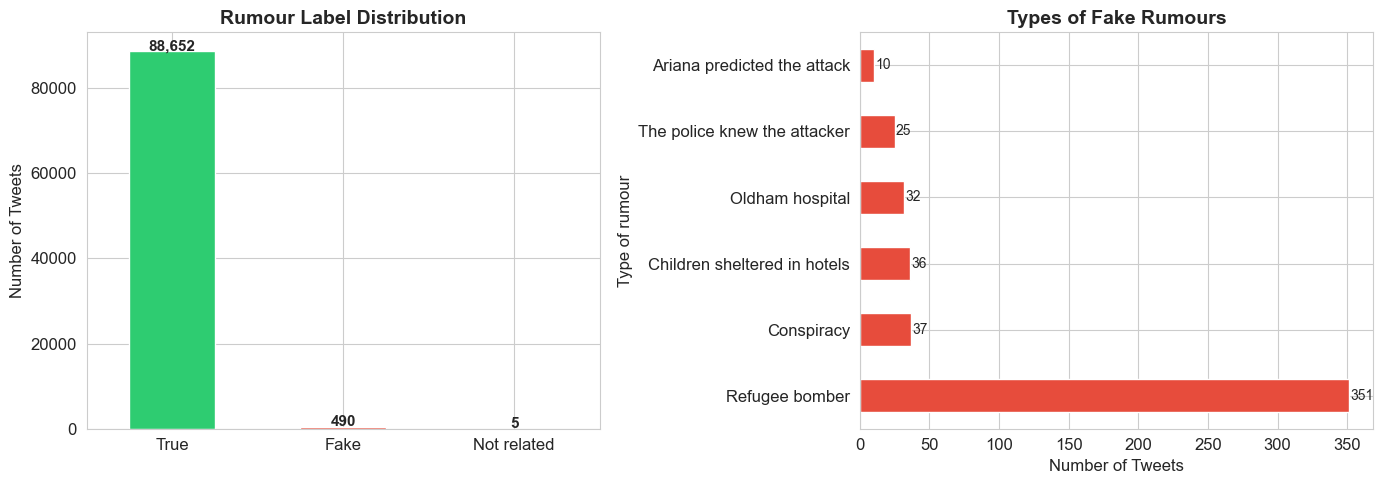

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Rumour distribution
colors = {'True': '#2ecc71', 'Fake': '#e74c3c', 'Not related': '#95a5a6'}
ax1 = axes[0]
bars = rumour_counts.plot(kind='bar', ax=ax1,
                          color=[colors.get(x, '#3498db') for x in rumour_counts.index],
                          edgecolor='white')
ax1.set_title('Rumour Label Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('')
ax1.set_ylabel('Number of Tweets')
ax1.tick_params(axis='x', rotation=0)
for bar, val in zip(ax1.patches, rumour_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'{val:,}', ha='center', fontsize=11, fontweight='bold')

# Plot 2: Type of rumour
ax2 = axes[1]
type_counts = df['Type of rumour'].value_counts()
type_counts.plot(kind='barh', ax=ax2, color='#e74c3c', edgecolor='white')
ax2.set_title('Types of Fake Rumours', fontsize=14, fontweight='bold')
ax2.set_xlabel('Number of Tweets')
for i, val in enumerate(type_counts.values):
    ax2.text(val + 1, i, f'{val}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}01_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. ניתוח אורך ציוצים

In [28]:
df['tweet_length'] = df['OrigTweet'].str.len()
df['word_count'] = df['OrigTweet'].str.split().str.len()

print('סטטיסטיקות אורך ציוצים:')
stats = df.groupby('Rumour_norm')[['tweet_length', 'word_count']].describe().round(1)
print(stats[['tweet_length', 'word_count']].to_string())

סטטיסטיקות אורך ציוצים:
            tweet_length                                                 word_count                                           
                   count   mean   std    min    25%    50%    75%    max      count  mean   std   min   25%   50%   75%    max
Rumour_norm                                                                                                                   
Fake               490.0  204.4  82.8   42.0  133.2  197.5  278.0  923.0      490.0  31.1  14.1   3.0  18.0  30.0  44.0   97.0
Not related          5.0  142.2   1.8  139.0  143.0  143.0  143.0  143.0        5.0  14.2   1.6  13.0  13.0  14.0  14.0   17.0
True             88652.0  143.0  61.1   28.0  103.0  128.0  158.0  956.0    88652.0  19.6  10.6   1.0  13.0  16.0  22.0  101.0


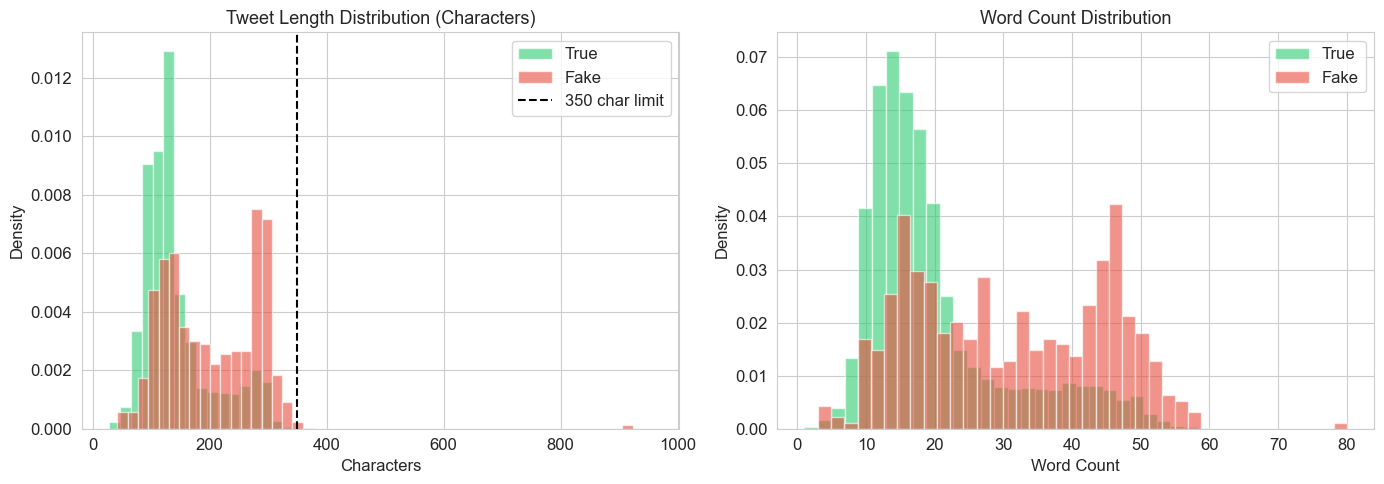

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tweet length
for label, color in [('True', '#2ecc71'), ('Fake', '#e74c3c')]:
    subset = df[df['Rumour_norm'] == label]['tweet_length']
    axes[0].hist(subset, bins=50, alpha=0.6, label=label, color=color, density=True)
axes[0].set_title('Tweet Length Distribution (Characters)', fontsize=13)
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].axvline(350, color='black', linestyle='--', label='350 char limit')
axes[0].legend()

# Word count
for label, color in [('True', '#2ecc71'), ('Fake', '#e74c3c')]:
    subset = df[df['Rumour_norm'] == label]['word_count'].clip(0, 80)
    axes[1].hist(subset, bins=40, alpha=0.6, label=label, color=color, density=True)
axes[1].set_title('Word Count Distribution', fontsize=13)
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}02_tweet_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. ניתוח סנטימנט (mVader)

In [30]:
print('ממוצע סנטימנט לפי קטגוריה:')
sentiment_stats = df.groupby('Rumour_norm')['mVader'].agg(['mean', 'median', 'std']).round(3)
print(sentiment_stats)

ממוצע סנטימנט לפי קטגוריה:
              mean  median    std
Rumour_norm                      
Fake        -0.460  -0.700  0.502
Not related  0.057   0.000  0.403
True        -0.518  -0.649  0.418


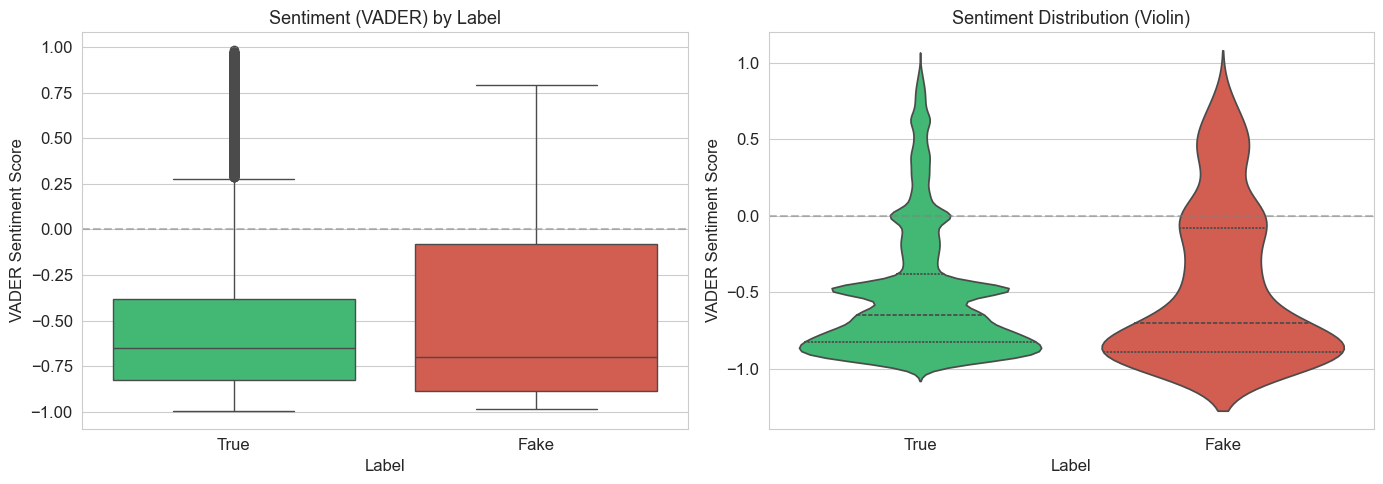

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_df = df[df['Rumour_norm'].isin(['True', 'Fake'])]

# Boxplot
sns.boxplot(data=plot_df, x='Rumour_norm', y='mVader', ax=axes[0],
            palette={'True': '#2ecc71', 'Fake': '#e74c3c'})
axes[0].set_title('Sentiment (VADER) by Label', fontsize=13)
axes[0].set_xlabel('Label')
axes[0].set_ylabel('VADER Sentiment Score')
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.5)

# Violin plot
sns.violinplot(data=plot_df, x='Rumour_norm', y='mVader', ax=axes[1],
               palette={'True': '#2ecc71', 'Fake': '#e74c3c'}, inner='quartile')
axes[1].set_title('Sentiment Distribution (Violin)', fontsize=13)
axes[1].set_xlabel('Label')
axes[1].set_ylabel('VADER Sentiment Score')
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}03_sentiment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. ניתוח מטא-דאטה (engagement)

In [32]:
engagement_cols = ['mRetweets', 'mLikes', 'mReplies', 'mHasURL', 'mHasMedia']
print('ממוצע מדדי engagement לפי קטגוריה:')
eng_stats = df.groupby('Rumour_norm')[engagement_cols].mean().round(2)
print(eng_stats)

ממוצע מדדי engagement לפי קטגוריה:
             mRetweets  mLikes  mReplies  mHasURL  mHasMedia
Rumour_norm                                                 
Fake              2.30    4.57      0.56     0.52       0.10
Not related       0.00    0.00      0.00     1.00       0.80
True              5.32   13.17      0.91     0.87       0.25


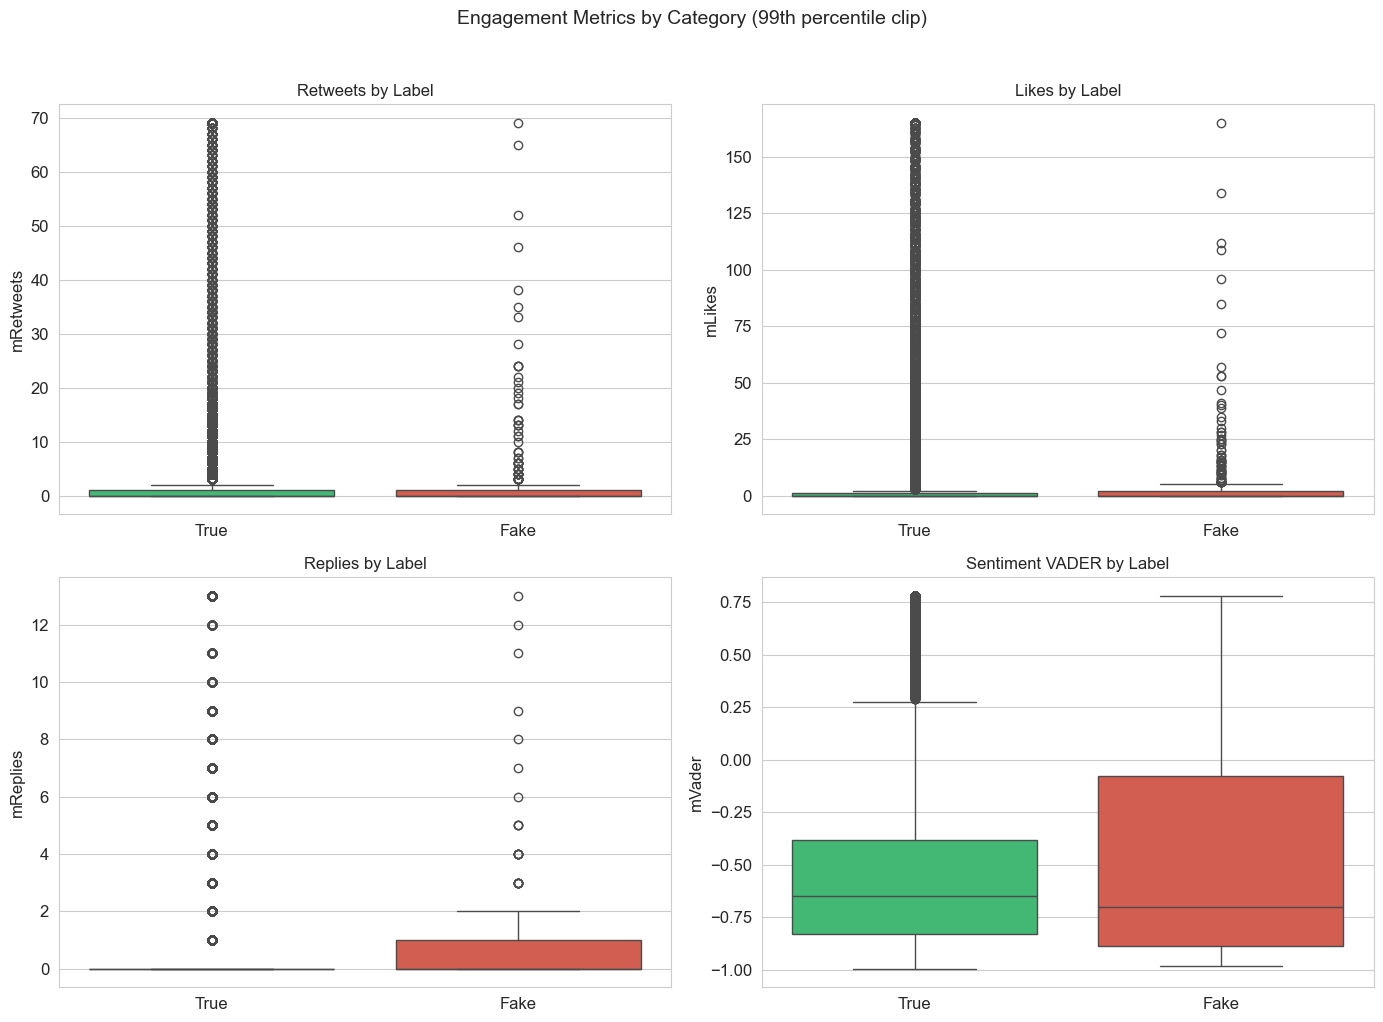

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

plot_df = df[df['Rumour_norm'].isin(['True', 'Fake'])]

for i, (col, title) in enumerate([('mRetweets', 'Retweets'), ('mLikes', 'Likes'),
                                    ('mReplies', 'Replies'), ('mVader', 'Sentiment VADER')]):
    clipped = plot_df[col].clip(upper=plot_df[col].quantile(0.99))
    temp_df = plot_df.copy()
    temp_df[col] = clipped
    sns.boxplot(data=temp_df, x='Rumour_norm', y=col, ax=axes[i],
                palette={'True': '#2ecc71', 'Fake': '#e74c3c'})
    axes[i].set_title(f'{title} by Label', fontsize=12)
    axes[i].set_xlabel('')

plt.suptitle('Engagement Metrics by Category (99th percentile clip)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}04_engagement_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

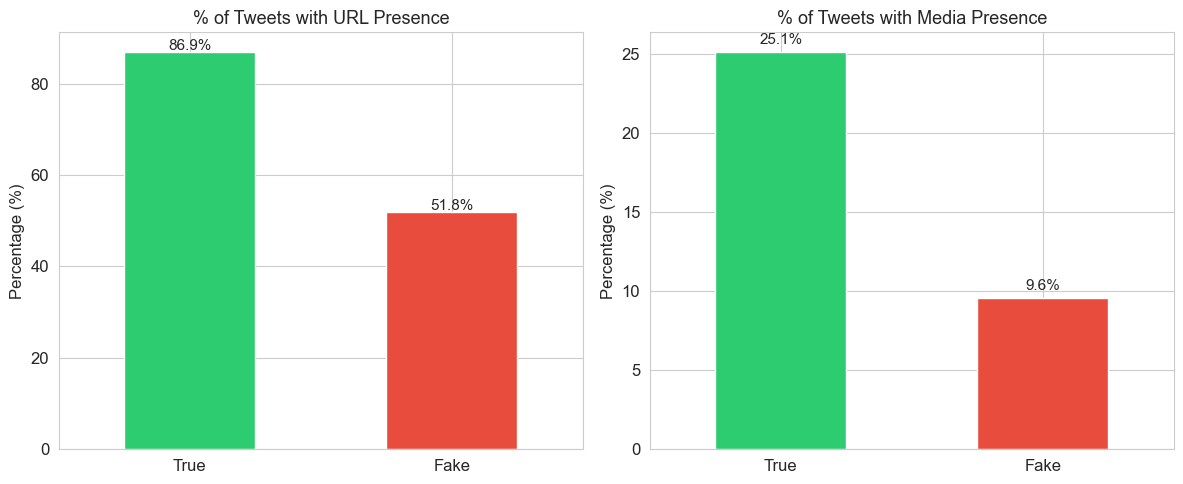

In [34]:
# URL and Media presence
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, title in [(axes[0], 'mHasURL', 'URL Presence'), (axes[1], 'mHasMedia', 'Media Presence')]:
    cross = df.groupby('Rumour_norm')[col].mean() * 100
    cross = cross[['True', 'Fake']]
    bars = cross.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'], edgecolor='white')
    ax.set_title(f'% of Tweets with {title}', fontsize=13)
    ax.set_ylabel('Percentage (%)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)
    for bar, val in zip(ax.patches, cross.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}05_url_media_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. ניתוח זמני (Temporal Analysis)

In [35]:
df['CreatedAt'] = pd.to_datetime(df['CreatedAt'], utc=True)
df['date'] = df['CreatedAt'].dt.date

print(f'טווח תאריכים: {df["CreatedAt"].min()} עד {df["CreatedAt"].max()}')
print(f'מספר ימים: {(df["CreatedAt"].max() - df["CreatedAt"].min()).days}')

טווח תאריכים: 2017-05-22 21:36:24+00:00 עד 2023-03-22 18:13:41+00:00
מספר ימים: 2129


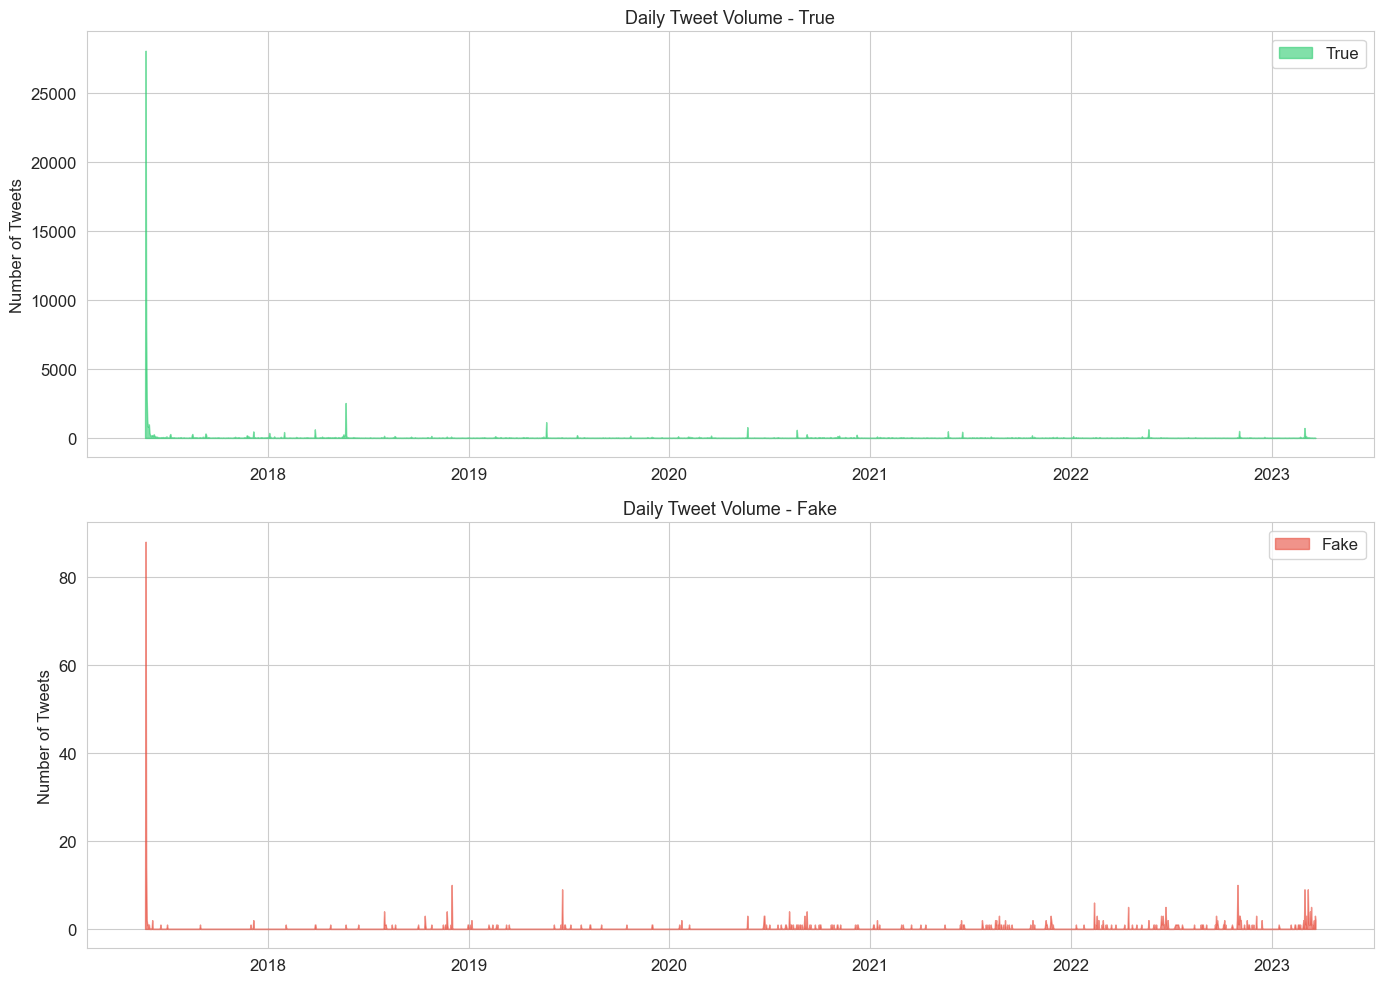

In [36]:
daily_counts = df.groupby(['date', 'Rumour_norm']).size().unstack(fill_value=0)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

if 'True' in daily_counts.columns:
    axes[0].fill_between(daily_counts.index, daily_counts.get('True', 0),
                          alpha=0.6, color='#2ecc71', label='True')
axes[0].set_title('Daily Tweet Volume - True', fontsize=13)
axes[0].set_ylabel('Number of Tweets')
axes[0].legend()

if 'Fake' in daily_counts.columns:
    axes[1].fill_between(daily_counts.index, daily_counts.get('Fake', 0),
                          alpha=0.6, color='#e74c3c', label='Fake')
axes[1].set_title('Daily Tweet Volume - Fake', fontsize=13)
axes[1].set_ylabel('Number of Tweets')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}06_temporal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. ניתוח תוכן - מילים נפוצות

In [37]:
def clean_for_words(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'[^a-z\s]', '', text)
    return text

STOPWORDS = set(['the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to',
                  'for', 'of', 'with', 'is', 'it', 'this', 'that', 'are', 'was',
                  'were', 'be', 'been', 'have', 'has', 'had', 'do', 'does', 'did',
                  'will', 'would', 'could', 'should', 'may', 'might', 'i', 'you',
                  'he', 'she', 'we', 'they', 'my', 'your', 'his', 'her', 'our',
                  'their', 'not', 'no', 'so', 'if', 'as', 'by', 'from', 'up',
                  'about', 'into', 'through', 'rt', 'amp'])

def get_top_words(texts, n=20):
    words = []
    for text in texts:
        cleaned = clean_for_words(text)
        words.extend([w for w in cleaned.split() if w not in STOPWORDS and len(w) > 2])
    return Counter(words).most_common(n)

print('20 מילים נפוצות ביותר בציוצי Fake:')
fake_tweets = df[df['Rumour_norm'] == 'Fake']['OrigTweet']
for word, count in get_top_words(fake_tweets):
    print(f'  {word}: {count}')

20 מילים נפוצות ביותר בציוצי Fake:
  manchester: 417
  arena: 374
  attack: 252
  bomb: 134
  children: 111
  who: 104
  refugees: 92
  asylum: 84
  terror: 78
  refugee: 78
  people: 72
  abedi: 62
  many: 61
  all: 58
  after: 57
  salman: 53
  how: 52
  rescued: 51
  more: 51
  bomber: 51


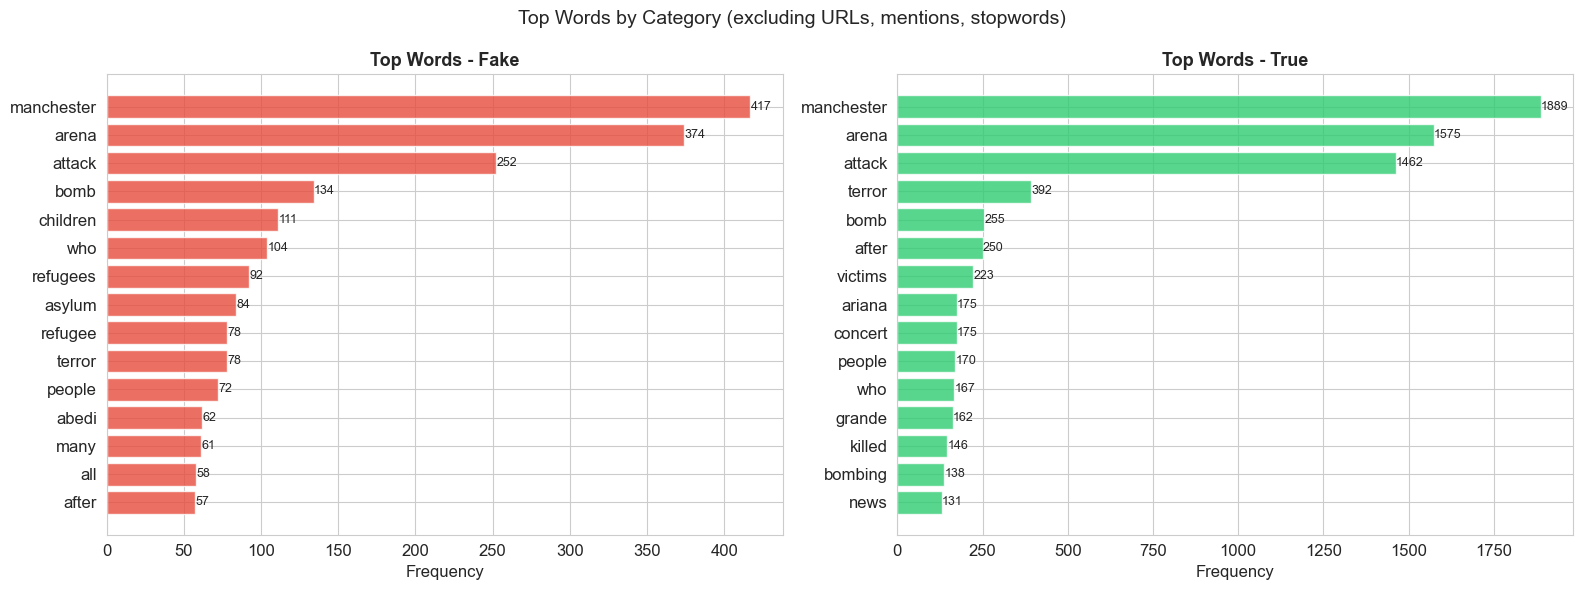

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, label, color in [(axes[0], 'Fake', '#e74c3c'), (axes[1], 'True', '#2ecc71')]:
    subset = df[df['Rumour_norm'] == label]['OrigTweet'].sample(min(2000, len(df[df['Rumour_norm'] == label])), random_state=42)
    top_words = get_top_words(subset, n=15)
    words, counts = zip(*top_words)
    bars = ax.barh(words[::-1], counts[::-1], color=color, alpha=0.8, edgecolor='white')
    ax.set_title(f'Top Words - {label}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Frequency')
    for bar, val in zip(ax.patches, counts[::-1]):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=9)

plt.suptitle('Top Words by Category (excluding URLs, mentions, stopwords)', fontsize=14)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}07_top_words.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. t-SNE Visualization

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder

# --- Sample: all 490 Fake + 1000 True (balanced-ish, fast to run) ---
fake_sample = df[df["Rumour_norm"] == "Fake"].copy()
true_sample = df[df["Rumour_norm"] == "True"].sample(1000, random_state=42).copy()
tsne_df = pd.concat([fake_sample, true_sample], ignore_index=True)

def clean_for_tsne(text):
    t = str(text).lower()
    t = re.sub(r"http\S+|www\.\S+", "", t)
    t = re.sub(r"@\w+", "", t)
    t = re.sub(r"#(\w+)", r"", t)
    t = re.sub(r"[^a-z\s]", " ", t)
    return re.sub(r"\s+", " ", t).strip()

tsne_df["clean"] = tsne_df["OrigTweet"].apply(clean_for_tsne)

print("Running TF-IDF...")
vectorizer = TfidfVectorizer(max_features=500, min_df=2, stop_words="english")
X = vectorizer.fit_transform(tsne_df["clean"]).toarray()

print("Running t-SNE (this may take ~30 seconds)...")
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42, verbose=0)
X_2d = tsne.fit_transform(X)

tsne_df["tsne_x"] = X_2d[:, 0]
tsne_df["tsne_y"] = X_2d[:, 1]
tsne_df["rumour_type_filled"] = tsne_df["Type of rumour"].fillna("Reliable")
print("Done.")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

color_map = {"True": "#2ecc71", "Fake": "#e74c3c"}
for label in ["True", "Fake"]:
    mask = tsne_df["Rumour_norm"] == label
    axes[0].scatter(tsne_df.loc[mask, "tsne_x"], tsne_df.loc[mask, "tsne_y"],
                    c=color_map[label], label=label, alpha=0.6,
                    s=20 if label == "True" else 40,
                    edgecolors="none" if label == "True" else "black", linewidths=0.3)
axes[0].set_title("t-SNE: Reliable vs. Misinformation", fontsize=14, fontweight="bold")
axes[0].set_xlabel("t-SNE Dimension 1")
axes[0].set_ylabel("t-SNE Dimension 2")
axes[0].legend(markerscale=2, fontsize=11)
axes[0].set_xticks([]); axes[0].set_yticks([])

type_colors = {
    "Refugee bomber":               "#e74c3c",
    "Conspiracy":                   "#9b59b6",
    "Children sheltered in hotels": "#e67e22",
    "Oldham hospital":              "#3498db",
    "The police knew the attacker": "#1abc9c",
    "Ariana predicted the attack":  "#f39c12",
    "Reliable":                     "#2ecc71",
}
for rtype, color in type_colors.items():
    mask = tsne_df["rumour_type_filled"] == rtype
    if mask.sum() == 0: continue
    axes[1].scatter(tsne_df.loc[mask, "tsne_x"], tsne_df.loc[mask, "tsne_y"],
                    c=color, label=rtype, alpha=0.6,
                    s=15 if rtype == "Reliable" else 45,
                    edgecolors="none" if rtype == "Reliable" else "black", linewidths=0.3)
axes[1].set_title("t-SNE: Fake Tweets by Rumour Type", fontsize=14, fontweight="bold")
axes[1].set_xlabel("t-SNE Dimension 1")
axes[1].set_ylabel("t-SNE Dimension 2")
axes[1].legend(markerscale=2, fontsize=9, loc="best")
axes[1].set_xticks([]); axes[1].set_yticks([])

plt.suptitle("t-SNE of Tweet Text (TF-IDF, 500 features) | n=1,490 tweets (490 Fake + 1,000 True)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}08_tsne.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. EDA Summary

In [39]:
print('='*60)
print('סיכום ממצאי EDA - Manchester Dataset')
print('='*60)
print(f'\n סה"כ ציוצים: {len(df):,}')
print(f' Fake (מידע כוזב): {(df["Rumour_norm"]=="Fake").sum():,} ({(df["Rumour_norm"]=="Fake").mean()*100:.1f}%)')
print(f' True (מידע אמין): {(df["Rumour_norm"]=="True").sum():,} ({(df["Rumour_norm"]=="True").mean()*100:.1f}%)')
print(f'\n ממוצע אורך ציוץ: {df["tweet_length"].mean():.0f} תווים')
print(f' אחוז ציוצים עם URL: {df["mHasURL"].mean()*100:.1f}%')
print(f' אחוז ציוצים עם מדיה: {df["mHasMedia"].mean()*100:.1f}%')
print(f'\n סנטימנט ממוצע:')
print(f'   Fake: {df[df["Rumour_norm"]=="Fake"]["mVader"].mean():.3f}')
print(f'   True: {df[df["Rumour_norm"]=="True"]["mVader"].mean():.3f}')
print(f'\n אורכי ציוצים > 350 תווים: {(df["tweet_length"] > 350).sum():,} ({(df["tweet_length"] > 350).mean()*100:.1f}%)')
print(f'\n סוגי מידע כוזב (Type of rumour):')
for t, c in df['Type of rumour'].value_counts().items():
    print(f'   {t}: {c}')
print('='*60)

סיכום ממצאי EDA - Manchester Dataset

 סה"כ ציוצים: 89,147
 Fake (מידע כוזב): 490 (0.5%)
 True (מידע אמין): 88,652 (99.4%)

 ממוצע אורך ציוץ: 143 תווים
 אחוז ציוצים עם URL: 86.7%
 אחוז ציוצים עם מדיה: 25.1%

 סנטימנט ממוצע:
   Fake: -0.460
   True: -0.518

 אורכי ציוצים > 350 תווים: 97 (0.1%)

 סוגי מידע כוזב (Type of rumour):
   Refugee bomber: 351
   Conspiracy: 37
   Children sheltered in hotels: 36
   Oldham hospital: 32
   The police knew the attacker: 25
   Ariana predicted the attack: 10
